In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

In [2]:
# Set plot style for professional look
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline


In [3]:
# 1. Extract Historical Financial Data
import yfinance as yf

tickers = ['TSLA', 'BND', 'SPY']
start_date = '2015-01-01'
end_date = '2026-01-15'

raw_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)
df = raw_data['Close']


[*********************100%***********************]  3 of 3 completed


In [4]:
print(f"Data downloaded: {df.shape[0]} rows for tickers {tickers}")

Data downloaded: 2775 rows for tickers ['TSLA', 'BND', 'SPY']


In [5]:
# Check basic statistics
print("--- Summary Statistics ---")
display(df.describe())
# Check basic statistics
print("--- Summary Statistics ---")
display(df.describe())


--- Summary Statistics ---


Ticker,BND,SPY,TSLA
count,2775.000000,2775.000000,2775.000000
mean,67.325727,339.074725,138.472937
std,4.685294,141.925743,131.682073
min,59.698601,154.980911,9.578000
25%,63.436434,219.599648,17.851666
50%,66.492081,301.538544,91.625999
75%,71.237354,423.938492,242.028336
max,76.068115,695.159973,489.880005


--- Summary Statistics ---


Ticker,BND,SPY,TSLA
count,2775.000000,2775.000000,2775.000000
mean,67.325727,339.074725,138.472937
std,4.685294,141.925743,131.682073
min,59.698601,154.980911,9.578000
25%,63.436434,219.599648,17.851666
50%,66.492081,301.538544,91.625999
75%,71.237354,423.938492,242.028336
max,76.068115,695.159973,489.880005


In [6]:
# Check data types and null values
print("\n--- Data Quality Check ---")
print(df.info())
print("\nMissing values per asset:")
print(df.isnull().sum())


--- Data Quality Check ---
<class 'pandas.DataFrame'>
DatetimeIndex: 2775 entries, 2015-01-02 to 2026-01-14
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   BND     2775 non-null   float64
 1   SPY     2775 non-null   float64
 2   TSLA    2775 non-null   float64
dtypes: float64(3)
memory usage: 86.7 KB
None

Missing values per asset:
Ticker
BND     0
SPY     0
TSLA    0
dtype: int64


In [7]:
# 2. Handle missing values
# We use forward fill because a missing price in stocks usually means the market was closed;
# the value remains the same as the last available trading day.
df = df.ffill()

# Verify cleaning
print(f"Missing values after ffill: {df.isnull().sum().sum()}")

Missing values after ffill: 0


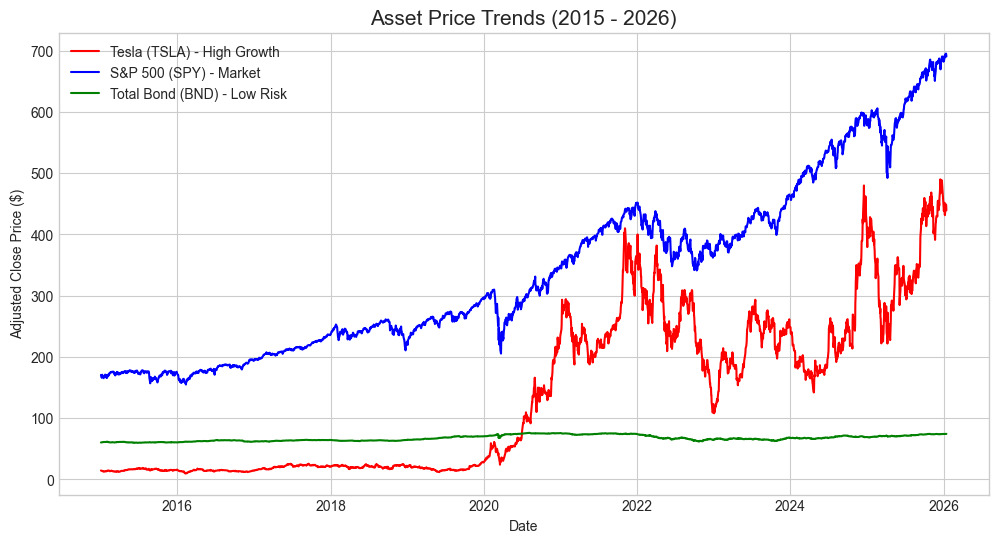

In [8]:
# Visualize the closing price over time
plt.figure(figsize=(12, 6))
plt.plot(df['TSLA'], label='Tesla (TSLA) - High Growth', color='red')
plt.plot(df['SPY'], label='S&P 500 (SPY) - Market', color='blue')
plt.plot(df['BND'], label='Total Bond (BND) - Low Risk', color='green')
plt.title("Asset Price Trends (2015 - 2026)", fontsize=15)
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price ($)")
plt.legend()
plt.show()

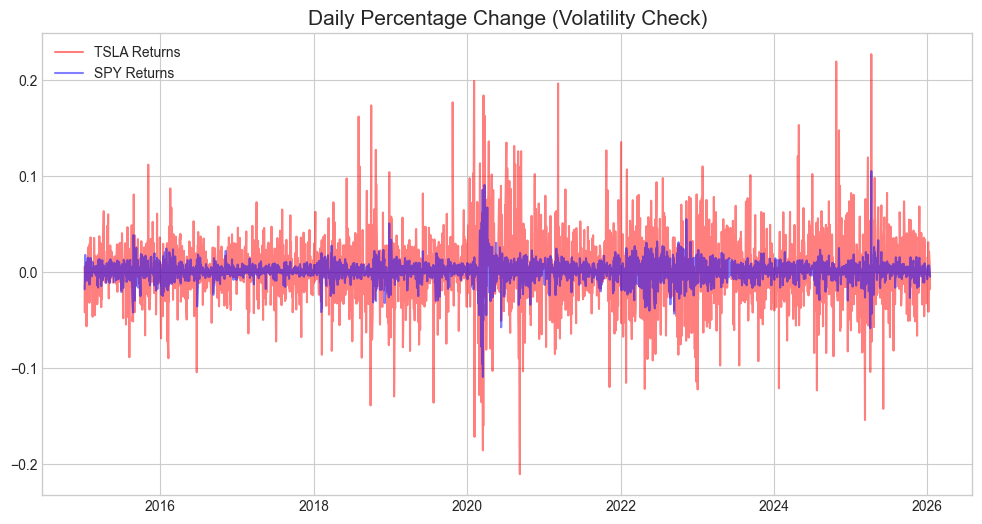

In [9]:
# Calculate daily percentage change (Returns)
returns = df.pct_change().dropna()

# Plot Daily Returns
plt.figure(figsize=(12, 6))
plt.plot(returns['TSLA'], label='TSLA Returns', alpha=0.5, color='red')
plt.plot(returns['SPY'], label='SPY Returns', alpha=0.5, color='blue')
plt.title("Daily Percentage Change (Volatility Check)", fontsize=15)
plt.legend()
plt.show()

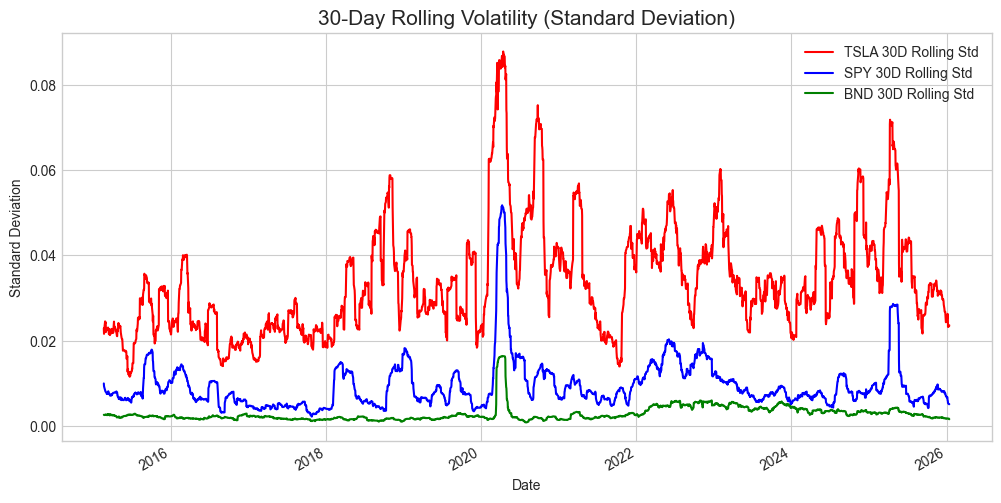

In [10]:
# Analyze volatility by calculating 30-day rolling standard deviations
plt.figure(figsize=(12, 6))
returns['TSLA'].rolling(window=30).std().plot(label='TSLA 30D Rolling Std', color='red')
returns['SPY'].rolling(window=30).std().plot(label='SPY 30D Rolling Std', color='blue')
returns['BND'].rolling(window=30).std().plot(label='BND 30D Rolling Std', color='green')
plt.title("30-Day Rolling Volatility (Standard Deviation)", fontsize=15)
plt.ylabel("Standard Deviation")
plt.legend()
plt.show()

In [11]:
# Identify days with unusually high or low returns (Outliers)
# Using a simple threshold of 3 standard deviations
tsla_mean = returns['TSLA'].mean()
tsla_std = returns['TSLA'].std()
outliers = returns[(returns['TSLA'] > tsla_mean + 3*tsla_std) | (returns['TSLA'] < tsla_mean - 3*tsla_std)]

print(f"Number of unusual return days for TSLA: {len(outliers)}")
print("Sample of extreme return days:")
display(outliers['TSLA'].sort_values().head(5)) # Worst days
display(outliers['TSLA'].sort_values().tail(5)) # Best days

Number of unusual return days for TSLA: 44
Sample of extreme return days:


Date
2020-09-08   -0.210628
2020-03-16   -0.185778
2020-02-05   -0.171758
2020-03-18   -0.160344
2025-03-10   -0.154262
Name: TSLA, dtype: float64

Date
2020-03-19    0.183877
2021-03-09    0.196412
2020-02-03    0.198949
2024-10-24    0.219190
2025-04-09    0.226900
Name: TSLA, dtype: float64

In [12]:
def check_stationarity(series, name):
    result = adfuller(series)
    print(f'--- ADF Test for {name} ---')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] < 0.05:
        print("Conclusion: The series is Stationary.")
    else:
        print("Conclusion: The series is Non-Stationary (Needs differencing).")

# Perform test on Prices
check_stationarity(df['TSLA'], "TSLA Price")

# Perform test on Returns
check_stationarity(returns['TSLA'], "TSLA Daily Returns")

--- ADF Test for TSLA Price ---
ADF Statistic: -0.7802
p-value: 0.8249
Conclusion: The series is Non-Stationary (Needs differencing).
--- ADF Test for TSLA Daily Returns ---
ADF Statistic: -53.0196
p-value: 0.0000
Conclusion: The series is Stationary.


In [13]:
# 5.1 Value at Risk (VaR) - 95% Confidence
# This means there is a 5% chance that the daily loss will exceed this value.
var_95 = returns.quantile(0.05)
print("--- Value at Risk (95% Confidence) ---")
print(var_95)

# 5.2 Sharpe Ratio (Historical Risk-Adjusted Returns)
# Assume Risk-Free Rate = 2% annually (0.02 / 252 trading days)
risk_free_rate_daily = 0.02 / 252
sharpe_ratios = ((returns.mean() - risk_free_rate_daily) / returns.std()) * np.sqrt(252)

print("\n--- Annualized Sharpe Ratios ---")
print(sharpe_ratios)

--- Value at Risk (95% Confidence) ---
Ticker
BND    -0.004796
SPY    -0.016719
TSLA   -0.052529
Name: 0.05, dtype: float64

--- Annualized Sharpe Ratios ---
Ticker
BND     0.008097
SPY     0.691428
TSLA    0.788518
dtype: float64
